# Libraries

In [144]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from datetime import datetime
from scipy.interpolate import griddata #Contour plots
from matplotlib import rcParams

# Set global font to Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']

In [145]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\K2SO4\20240607 - Ag60 GDE_0.9 M K2SO4_pH1

11-Aug-26  04:04 PM    <DIR>          .
07-Jun-26  07:23 PM    <DIR>          ..
07-Jun-26  08:59 PM    <DIR>          .ipynb_checkpoints
10-Jun-24  02:39 PM           137,757 0p9M_pH1 K2SO4_20240610_1239_1min - Copy.xlsx
29-Jul-26  06:36 PM           113,714 0p9M_pH1 K2SO4_20240610_1239_1min.xlsx
10-Jun-24  02:39 PM            32,283 0p9M_pH1 K2SO4_20240610_1239_5min.xlsx
10-Jun-24  02:39 PM           962,711 0p9M_pH1 K2SO4_20240610_1239_Line_1.csv
12-May-25  11:18 AM           812,967 20240607 - Ag60 GDE_0.9 M K2SO4_pH1.ipynb
11-Aug-26  08:57 AM           704,028 20240607 - Ag60 GDE_0.9 M K2SO4_pH1-CORRECTED.ipynb
11-Aug-26  08:49 AM               556 20240607_0.9 M K2SO4_pH1_Energy Consumption.csv
11-Aug-26  08:55 AM             5,802 20240607_0.9M K2SO4_pH1.csv
11-Aug-26  08:49 AM             1,407 20

# Load Data

In [146]:
Book = "Book_20240607 - Ag60 GDE_0.9 M K2SO4_pH1.xlsx"
Book = pd.read_excel(Book)
Book.head(3)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(H2),c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24
0,Ag60 GDE in PTFE holder,60,67.7,0.3 M K2SO4,Deionized wated,CCM-CEM,0.000,2024-06-07 16:53:31.479,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000
1,Ag60 GDE in PTFE holder,60,67.7,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-07 17:12:14.000,0.311811,1.624289,...,0.015722,0.000087,0.980108,0.001079,1.316586,0.007314,NaN,1.323899,0.000089,NaN
2,Ag60 GDE in PTFE holder,60,70.4,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-07 17:34:45.000,0.687089,1.668069,...,0.016157,0.000052,0.980189,0.000921,1.407003,0.004560,NaN,1.411563,0.000053,101.198329


In [147]:
Book["Duration / h"] = round(Book["Duration / h"],2)
Book["Flow rate (ml min-1)"] = round(Book["Flow rate (ml min-1)"],2)
# Flow_df = Book[["Time", "Duration / h", "Flow rate (ml min-1)"]].copy()
Book["GC_flow_rate_ml_min"] = Book["Flow rate (ml min-1)"]
Book.tail(3)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min
123,Ag60 GDE in PTFE holder,60,73.9,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.5,2024-06-09 18:08:58,49.26,12.855273,...,0.034545,0.839797,0.000524,2.447556,0.675763,NaN,3.123319,0.039510,NaN,73.9
124,Ag60 GDE in PTFE holder,60,73.3,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.5,2024-06-09 18:31:29,49.63,0.907525,...,0.003449,0.987156,0.000527,0.171853,0.066915,NaN,0.238768,0.003481,101.500772,73.3
125,Ag60 GDE in PTFE holder,60,73.0,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.5,2024-06-09 18:54:00,50.01,0.089399,...,0.000138,0.998459,0.000519,0.016869,0.002673,NaN,0.019542,0.000139,NaN,73.0


#### Temp from pH meter

In [148]:
Temp = "2024-06-08_102720.csv"
Temp = pd.read_csv(Temp)
Temp[["Supp Reading 1", "Supp Units 1"]]
Temp_C_mean = Temp["Supp Reading 1"].mean()
Temp_C_median = Temp["Supp Reading 1"].median()

print("Temp C mean:", Temp_C_mean)
print("Temp C median:", Temp_C_median)

Temp C mean: 24.870800351802988
Temp C median: 23.9


### Power Supply

In [149]:
power_sup = "Power supply_1.csv"
power_sup = pd.read_csv(power_sup, sep=";")
power_sup.head(2)

,U set,U actual,I set,I actual,P set,P actual,R set,R actual,R mode,Output/Input,Device mode,Error,Time
0,0.00V,0.23V,0.000A,0.000A,320.00W,0.00W,NaN,NaN,NaN,On,CV,NaN,07.06.2024 16:53:31.479
1,40.00V,1.93V,0.100A,0.098A,320.00W,0.00W,NaN,NaN,NaN,On,CC,NaN,07.06.2024 16:53:36.470


In [150]:
power_sup.groupby("I set", group_keys=True)[['U actual']].apply(lambda x: x).head(3)

U actual
I set                
0.000A 0        0.23V
       17282    2.40V
0.100A 1        1.93V

In [151]:
power_sup["Time"] = pd.to_datetime(
    power_sup["Time"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

power_sup["I actual"] = (
    power_sup["I actual"]
    .str.replace("A", "", regex=False)
    .str.strip()
    .astype(float)
)
power_sup["U actual"] = (
    power_sup["U actual"]
    .str.replace("V", "", regex=False)
    .str.strip()
    .astype(float)
)

# Set time as index
power_sup = power_sup.set_index("Time")

# Mean current and voltage every 2 hours
power_summary = (
    power_sup.resample("2h")
    .agg({
        "I actual": "max",
        "U actual": "max"
    })
    .reset_index()
)

# Rename column
# I_mean = I_mean.rename(columns={"I actual": "I actual_mean (A)"})
print(power_summary)

                  Time  I actual  U actual
0  2024-06-07 16:00:00     0.107      2.50
1  2024-06-07 18:00:00     0.262      2.95
2  2024-06-07 20:00:00     0.507      3.57
3  2024-06-07 22:00:00     0.758      4.16
4  2024-06-08 00:00:00     1.006      4.71
5  2024-06-08 02:00:00     1.501      6.01
6  2024-06-08 04:00:00     1.997      6.88
7  2024-06-08 06:00:00     2.996      7.90
8  2024-06-08 08:00:00     2.998      7.62
9  2024-06-08 10:00:00     1.503      5.28
10 2024-06-08 12:00:00     1.504      5.53
11 2024-06-08 14:00:00     1.502      5.64
12 2024-06-08 16:00:00     1.501      5.76
13 2024-06-08 18:00:00       NaN       NaN
14 2024-06-08 20:00:00       NaN       NaN
15 2024-06-08 22:00:00       NaN       NaN
16 2024-06-09 00:00:00       NaN       NaN
17 2024-06-09 02:00:00       NaN       NaN
18 2024-06-09 04:00:00       NaN       NaN
19 2024-06-09 06:00:00       NaN       NaN
20 2024-06-09 08:00:00       NaN       NaN
21 2024-06-09 10:00:00       NaN       NaN
22 2024-06-

In [152]:
# power_summary = power_summary.iloc[3:].reset_index(drop=True) #Power supply was recording before the experiment
# power_summary.loc[power_summary.index[0], "I actual"] = 0 #The first row will be taken is 0, not current was input
power_summary = power_summary.iloc[:-18].reset_index(drop=True) #after 16h
print(power_summary)

                 Time  I actual  U actual
0 2024-06-07 16:00:00     0.107      2.50
1 2024-06-07 18:00:00     0.262      2.95
2 2024-06-07 20:00:00     0.507      3.57
3 2024-06-07 22:00:00     0.758      4.16
4 2024-06-08 00:00:00     1.006      4.71
5 2024-06-08 02:00:00     1.501      6.01
6 2024-06-08 04:00:00     1.997      6.88
7 2024-06-08 06:00:00     2.996      7.90


In [153]:
# power_sup["U actual"] = power_sup["U actual"].str.replace("V", "", regex=False).astype(float)
# power_sup["I set"] = power_sup["I set"].str.replace("A", "", regex=False).astype(float)
# cell_voltage = power_sup.groupby("I set")["U actual"].mean()
# cell_voltage

In [154]:
dfcell_voltage = pd.DataFrame(power_summary)
dfcell_voltage = dfcell_voltage.rename(columns={"U actual": "Voltage"})
dfcell_voltage = dfcell_voltage.set_index("I actual")
dfcell_voltage = dfcell_voltage.drop(columns=["Time"])
dfcell_voltage

,Voltage
I actual,
0.107,2.50
0.262,2.95
0.507,3.57
0.758,4.16
1.006,4.71
1.501,6.01
1.997,6.88
2.996,7.90


In [155]:
dfcell_voltage["Current Density [mA cm-2]"] = dfcell_voltage.index*10
dfcell_voltage

,Voltage,Current Density [mA cm-2]
I actual,,
0.107,2.50,1.07
0.262,2.95,2.62
0.507,3.57,5.07
0.758,4.16,7.58
1.006,4.71,10.06
1.501,6.01,15.01
1.997,6.88,19.97
2.996,7.90,29.96


## Flow rate

In [156]:
flow_rate = "0p9M_pH1 K2SO4_20240610_1239_1min.xlsx"
flow_rate = pd.read_excel(flow_rate, sheet_name="Process data")
flow_rate.head(25)

,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,Report generated (UTC),2024-06-10 12:39:09.648000,NaN
1,Software version,Aurora 1.0.2,NaN
2,Instrument name,0p9M_pH1 K2SO4,NaN
3,Instrument model name,BPC Go,NaN
4,Ethernet mac address,f8:dc:7a:6e:f2:c4,NaN
5,Agitation state,Off,NaN
6,Agitation phase,Single,NaN
7,Agitation phase speed (%),30,NaN
8,Gas normalisation,Unnormalised,NaN
9,NaN,NaN,NaN


In [157]:
flow_rate = flow_rate.iloc[18:].reset_index(drop=True)
flow_rate = flow_rate.rename(columns={
    "Unnamed: 0": "Time (UTC)",
    "Unnamed: 1": "Gas flow rate [ml/min]",
    "Unnamed: 2": "Specific gas production [ml/min/l]"
})

flow_rate

,Time (UTC),Gas flow rate [ml/min],Specific gas production [ml/min/l]
0,2024-06-07 14:53:00.010000,54.073679,27.036839
1,2024-06-07 14:53:59.971000,55.232774,27.616387
2,2024-06-07 14:55:00.019000,55.897376,27.948688
3,2024-06-07 14:55:59.981000,56.07797,28.038985
4,2024-06-07 14:57:00.029000,55.890866,27.945433
...,...,...,...
967,2024-06-08 07:00:00.029000,68.571151,34.285575
968,2024-06-08 07:00:59.990000,68.753914,34.376957
969,2024-06-08 07:02:00.038000,68.888037,34.444018
970,2024-06-08 07:03:00,68.898378,34.449189


In [158]:
flow_rate["Time (UTC)"] = pd.to_datetime(
    flow_rate["Time (UTC)"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

# Set time as index
flow_rate = flow_rate.set_index("Time (UTC)")

# Mean current and voltage every 2 hours
flow_rate = (
    flow_rate.resample("2h")
    .agg(Flow_rate_min=("Gas flow rate [ml/min]", "min"), 
         Flow_rate_max=("Gas flow rate [ml/min]", "max"),
         Flow_rate_mean=("Gas flow rate [ml/min]", "mean"),
         Flow_rate_median=("Gas flow rate [ml/min]", "median"))
    .reset_index()
)

print(flow_rate)

           Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0 2024-06-07 14:00:00     54.073679     58.658725       57.13368   
1 2024-06-07 16:00:00     58.155745     62.019889      60.343308   
2 2024-06-07 18:00:00     61.193023     64.667015      62.937592   
3 2024-06-07 20:00:00     63.285164     66.862238      65.009352   
4 2024-06-07 22:00:00     65.734973     68.758462      67.190981   
5 2024-06-08 00:00:00     67.295245     72.199919      69.412159   
6 2024-06-08 02:00:00     69.128928     73.643833      71.318028   
7 2024-06-08 04:00:00     72.259077     82.322866      77.546216   
8 2024-06-08 06:00:00     67.074212     80.852519      78.384126   

  Flow_rate_median  
0        57.288939  
1         61.07936  
2        63.520926  
3        65.882151  
4        67.835557  
5        69.990774  
6         72.37376  
7        80.924035  
8        80.381906  


#### Correction dry flow

In [159]:
# ---- physical constants ---- For FE% later
F   = 96485        # Faraday constant                   [C/mol]
R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
T   = Temp_C_median + 273.15     # gas temperature at the meter       [K]  (~23.3 degC)
P   = 101325       # pressure                           [Pa]
V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- wet-to-dry correction ----
# The flow meter reads the wet gas leaving the cell. Assuming saturation at the
# meter temperature, water occupies x_H2O of the stream; the remaining fraction
# is product + carrier. p_sat from the Buck equation.
T_C   = Temp_C_median
P_SAT = 0.61121*np.exp((18.678 - T_C/234.5)*(T_C/(257.14 + T_C))) * 1000   # Pa
X_H2O = P_SAT / P                  # 0.0282 at 23.3 degC
DRY   = 1 - X_H2O                  # 0.9718

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]

print(f"V_m   = {V_m:.3f} L/mol")
print(f"p_sat = {P_SAT/1000:.4f} kPa -> x(H2O) = {X_H2O*100:.2f} % -> dry factor {DRY:.5f}")

V_m   = 24.374 L/mol
p_sat = 2.9666 kPa -> x(H2O) = 2.93 % -> dry factor 0.97072


In [160]:
FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]
for c in FLOW_COLS:
    flow_rate[c + "_dry"] = flow_rate[c] * DRY

# FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]

# for c in FLOW_COLS:
#     flow_rate[c + "_corr"] = flow_rate[c] * 0.9723

# flow_rate

In [161]:
print(flow_rate)

           Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0 2024-06-07 14:00:00     54.073679     58.658725       57.13368   
1 2024-06-07 16:00:00     58.155745     62.019889      60.343308   
2 2024-06-07 18:00:00     61.193023     64.667015      62.937592   
3 2024-06-07 20:00:00     63.285164     66.862238      65.009352   
4 2024-06-07 22:00:00     65.734973     68.758462      67.190981   
5 2024-06-08 00:00:00     67.295245     72.199919      69.412159   
6 2024-06-08 02:00:00     69.128928     73.643833      71.318028   
7 2024-06-08 04:00:00     72.259077     82.322866      77.546216   
8 2024-06-08 06:00:00     67.074212     80.852519      78.384126   

  Flow_rate_median Flow_rate_min_dry Flow_rate_max_dry Flow_rate_mean_dry  \
0        57.288939         52.490502         56.941307          55.460912   
1         61.07936         56.453053         60.204062          58.576568   
2        63.520926         59.401405         62.773685          61.094896   
3        65

In [162]:
dfflow_rate = pd.DataFrame(flow_rate)
dfflow_rate['Current [A]'] = power_summary['I actual']
dfflow_rate['Voltage'] = power_summary['U actual']
dfflow_rate = dfflow_rate.iloc[:-1].reset_index(drop=True)
dfflow_rate

,Time (UTC),Flow_rate_min,Flow_rate_max,Flow_rate_mean,Flow_rate_median,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_mean_dry,Flow_rate_median_dry,Current [A],Voltage
0,2024-06-07 14:00:00,54.073679,58.658725,57.13368,57.288939,52.490502,56.941307,55.460912,55.611626,0.107,2.50
1,2024-06-07 16:00:00,58.155745,62.019889,60.343308,61.07936,56.453053,60.204062,58.576568,59.29107,0.262,2.95
2,2024-06-07 18:00:00,61.193023,64.667015,62.937592,63.520926,59.401405,62.773685,61.094896,61.661152,0.507,3.57
3,2024-06-07 20:00:00,63.285164,66.862238,65.009352,65.882151,61.432292,64.904636,63.106,63.953244,0.758,4.16
4,2024-06-07 22:00:00,65.734973,68.758462,67.190981,67.835557,63.810375,66.745342,65.223754,65.849458,1.006,4.71
5,2024-06-08 00:00:00,67.295245,72.199919,69.412159,69.990774,65.324966,70.08604,67.3799,67.941575,1.501,6.01
6,2024-06-08 02:00:00,69.128928,73.643833,71.318028,72.37376,67.104962,71.487679,69.229969,70.254791,1.997,6.88
7,2024-06-08 04:00:00,72.259077,82.322866,77.546216,80.924035,70.143466,79.912606,75.275807,78.55473,2.996,7.90


In [163]:
# dfflow_rate.to_csv('20240607_0.9M K2SO4_pH1_flow rate.csv')

## Energy consumption

Units: cm2 to m2: 1000cm2 is 1m2.  <br>
mA to A: 1000mA is 1A.  <br>
hrs to sec: 1hr is 3600 <br>
10cm2 = 0.001m2. <br> 2hr = 7200 <br>
1Wh = 3600J

*Energy consumption* = Current density [A cm2]* time [s] * cell voltage [V] * area of the electrode [m2]

In [164]:
electrode_area = 10/10000 #10cm2 to m2
time = 2*3600 #2hrs

dfcell_voltage["Current Density [A m-2]"] = dfcell_voltage["Current Density [mA cm-2]"]*100 #10000/1000
dfcell_voltage.head(3)

,Voltage,Current Density [mA cm-2],Current Density [A m-2]
I actual,,,
0.107,2.50,1.07,107.0
0.262,2.95,2.62,262.0
0.507,3.57,5.07,507.0


In [165]:
dfcell_voltage["Energy Consumption [J]"] = dfcell_voltage.index * time * dfcell_voltage["Voltage"]
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J]
I actual,,,,
0.107,2.50,1.07,107.0,1926.000
0.262,2.95,2.62,262.0,5564.880
0.507,3.57,5.07,507.0,13031.928
0.758,4.16,7.58,758.0,22703.616
1.006,4.71,10.06,1006.0,34115.472
1.501,6.01,15.01,1501.0,64951.272
1.997,6.88,19.97,1997.0,98923.392
2.996,7.90,29.96,2996.0,170412.480


In [166]:
dfcell_voltage["Energy Consumption [kWh]"] = dfcell_voltage["Energy Consumption [J]"]/3600000 #1kWh is 3.6xe6 joules
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J],Energy Consumption [kWh]
I actual,,,,,
0.107,2.50,1.07,107.0,1926.000,0.000535
0.262,2.95,2.62,262.0,5564.880,0.001546
0.507,3.57,5.07,507.0,13031.928,0.003620
0.758,4.16,7.58,758.0,22703.616,0.006307
1.006,4.71,10.06,1006.0,34115.472,0.009477
1.501,6.01,15.01,1501.0,64951.272,0.018042
1.997,6.88,19.97,1997.0,98923.392,0.027479
2.996,7.90,29.96,2996.0,170412.480,0.047337


In [167]:
# dfcell_voltage.to_csv('20240607_0.9 M K2SO4_pH1_Energy Consumption.csv')

## FE(CO) and FE(H2)

## Integer Duration ("Applied Current /A" - Values optimization)

In [168]:
Book['Integer Duration'] = np.floor(Book['Duration / h'])
Book = Book[Book['Integer Duration'] < 16].copy()
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration
0,Ag60 GDE in PTFE holder,60,67.7,0.3 M K2SO4,Deionized wated,CCM-CEM,0.000,2024-06-07 16:53:31.479,0.00,0.000000,...,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,67.7,0.0
1,Ag60 GDE in PTFE holder,60,67.7,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-07 17:12:14.000,0.31,1.624289,...,0.980108,0.001079,1.316586,0.007314,NaN,1.323899,0.000089,NaN,67.7,0.0
2,Ag60 GDE in PTFE holder,60,70.4,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-07 17:34:45.000,0.69,1.668069,...,0.980189,0.000921,1.407003,0.004560,NaN,1.411563,0.000053,101.198329,70.4,0.0
3,Ag60 GDE in PTFE holder,60,68.9,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-07 17:57:16.000,1.06,1.651206,...,0.980752,0.000833,1.365182,0.003150,NaN,1.368332,0.000038,NaN,68.9,1.0
4,Ag60 GDE in PTFE holder,60,69.9,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-07 18:19:46.000,1.44,1.630547,...,0.983230,0.000746,1.379252,0.005053,NaN,1.384305,0.000059,100.506901,69.9,1.0
5,Ag60 GDE in PTFE holder,60,69.9,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-07 18:52:48.000,1.99,1.607644,...,0.983373,0.000802,1.361807,0.005059,NaN,1.366866,0.000059,NaN,69.9,1.0
6,Ag60 GDE in PTFE holder,60,67.9,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.275,2024-06-07 19:15:17.000,2.36,3.285215,...,0.967154,0.000619,1.051394,0.001316,NaN,1.052709,0.000042,98.760023,67.9,2.0
7,Ag60 GDE in PTFE holder,60,68.7,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.275,2024-06-07 19:37:48.000,2.74,3.303397,...,0.967014,0.000577,1.069556,0.001587,NaN,1.071143,0.000050,NaN,68.7,2.0
8,Ag60 GDE in PTFE holder,60,68.7,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.275,2024-06-07 20:00:18.000,3.11,3.303125,...,0.965058,0.000629,1.067305,0.001453,NaN,1.068758,0.000046,98.756587,68.7,3.0
9,Ag60 GDE in PTFE holder,60,68.6,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.275,2024-06-07 20:22:49.000,3.49,3.307168,...,0.967006,0.000549,1.069474,0.001299,NaN,1.070773,0.000041,NaN,68.6,3.0


## Current Density

In [169]:
Book["Current Density"] = (Book['Applied current / A']/10)*10000 #mA
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration,Current Density
0,Ag60 GDE in PTFE holder,60,67.7,0.3 M K2SO4,Deionized wated,CCM-CEM,0.000,2024-06-07 16:53:31.479,0.00,0.000000,...,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,67.7,0.0,0.0
1,Ag60 GDE in PTFE holder,60,67.7,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-07 17:12:14.000,0.31,1.624289,...,0.001079,1.316586,0.007314,NaN,1.323899,0.000089,NaN,67.7,0.0,-107.0
2,Ag60 GDE in PTFE holder,60,70.4,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-07 17:34:45.000,0.69,1.668069,...,0.000921,1.407003,0.004560,NaN,1.411563,0.000053,101.198329,70.4,0.0,-107.0
3,Ag60 GDE in PTFE holder,60,68.9,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-07 17:57:16.000,1.06,1.651206,...,0.000833,1.365182,0.003150,NaN,1.368332,0.000038,NaN,68.9,1.0,-107.0
4,Ag60 GDE in PTFE holder,60,69.9,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-07 18:19:46.000,1.44,1.630547,...,0.000746,1.379252,0.005053,NaN,1.384305,0.000059,100.506901,69.9,1.0,-107.0
5,Ag60 GDE in PTFE holder,60,69.9,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-07 18:52:48.000,1.99,1.607644,...,0.000802,1.361807,0.005059,NaN,1.366866,0.000059,NaN,69.9,1.0,-107.0
6,Ag60 GDE in PTFE holder,60,67.9,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.275,2024-06-07 19:15:17.000,2.36,3.285215,...,0.000619,1.051394,0.001316,NaN,1.052709,0.000042,98.760023,67.9,2.0,-275.0
7,Ag60 GDE in PTFE holder,60,68.7,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.275,2024-06-07 19:37:48.000,2.74,3.303397,...,0.000577,1.069556,0.001587,NaN,1.071143,0.000050,NaN,68.7,2.0,-275.0
8,Ag60 GDE in PTFE holder,60,68.7,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.275,2024-06-07 20:00:18.000,3.11,3.303125,...,0.000629,1.067305,0.001453,NaN,1.068758,0.000046,98.756587,68.7,3.0,-275.0
9,Ag60 GDE in PTFE holder,60,68.6,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.275,2024-06-07 20:22:49.000,3.49,3.307168,...,0.000549,1.069474,0.001299,NaN,1.070773,0.000041,NaN,68.6,3.0,-275.0


## FE(CO)

In [170]:
# Book["FE(CO)"] = Book["c(CO)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"]

In [171]:
# # ---- physical constants ----
# F   = 96485        # Faraday constant                   [C/mol]
# R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
# T   = 296.15       # gas temperature at the meter       [K]  (~23 degC)
# P   = 101325       # pressure                           [Pa]
# V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]
print(f"V_m = {V_m:.3f} L/mol")

V_m = 24.374 L/mol


In [172]:
currents     = [i for i in dfcell_voltage.index.to_list() if i != 0]
currents

[0.107, 0.262, 0.507, 0.758, 1.006, 1.501, 1.997, 2.996]

In [173]:
# Determine the 2 h step for each GC injection
step = (Book["Duration / h"] // 2).astype(int)

# Count injections per step
inj_per_step = step.value_counts().sort_index().tolist()
inj_per_step

[6, 5, 5, 5, 5, 5, 5, 5]

In [174]:
currents # The actual applied current from the power supply file (without the first 0)   # GC injections per step (estimate). From Book excel
inj_per_step # GC injections per step (2h)

I_seq = np.repeat(currents, inj_per_step)
# rows  = Book.iloc[first_row : first_row + len(I_seq)].copy().reset_index(drop=True)
rows = Book.iloc[:len(I_seq)].copy().reset_index(drop=True)
rows["Current_abs"] = rows["Applied current / A"].abs()

rows = rows.sort_values("Current_abs")
dfflow_rate = dfflow_rate.sort_values("Current [A]")

rows = pd.merge_asof(
    rows,
    dfflow_rate[["Current [A]", "Flow_rate_mean_dry", "Flow_rate_min_dry", "Flow_rate_max_dry", "Flow_rate_median_dry"]],
    left_on="Current_abs",
    right_on="Current [A]",
    direction="nearest"
)
# Clean columns
# rows = rows.drop(columns=["Current_abs", "Current [A]"])

rows["Applied current / A"] = -I_seq                    # cathodic -> negative
rows["Current Density"]     = rows["Applied current / A"] / 10 * 10000   # mA cm-2 10 is A_cm2 electrode

# check: c(H2) should rise monotonically from one step to the next
print(rows.groupby(rows["Applied current / A"].abs())[["c(H2)", "c(CO)"]].median().round(3))
# rows[["c(H2)", "c(CO)","FE(H2)", "FE(CO)"]].head(50)

                     c(H2)  c(CO)
Applied current / A              
0.107                0.016  0.000
0.262                0.032  0.000
0.507                0.059  0.000
0.758                0.083  0.000
1.006                0.106  0.001
1.501                0.133  0.021
1.997                0.162  0.034
2.996                0.235  0.032


In [177]:
def faradaic_efficiency(conc, flow_ml_min, current_A, n_electrons):
    gas_volume_ml_min = conc * flow_ml_min #Concentration in molar_fraction × flow_total = vol gas
    gas_volume_L_s = gas_volume_ml_min / 1000 / 60 #ml/min → L/s
    mol_per_s = gas_volume_L_s / V_m #volume → molar flow using V_m (Ideal gas law)
    charge_rate = mol_per_s * n_electrons * F # moles to amp. Each molecule carries z electrons
    FE = (charge_rate / abs(current_A)) * 100
    return FE

rows["FE(CO)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(CO)"], 
        row["Flow_rate_min_dry"],    # 2h period
        row["Current [A]"], 
        2
    ), 
    axis=1
)

rows["FE(H2)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(H2)"], 
        row["Flow_rate_min_dry"], 
        row["Current [A]"], 
        2
    ), 
    axis=1
)

# rows.loc[rows.index[0], "FE(H2)"] = 0
rows["FE(total)"] = rows["FE(H2)"] + rows["FE(CO)"]

# rows[["Current Density", "FE(H2)", "FE(CO)", "FE(total)"]].head(15)

# sanity check: H2 + CO must stay around / below 100 %
_tot = rows["FE(H2)"] + rows["FE(CO)"]
print(f"FE_total  min/max/mean = {_tot.min():.1f} / {_tot.max():.1f} / {_tot.mean():.1f} %")

FE_total  min/max/mean = 0.0 / 104.9 / 87.7 %


In [178]:
rows[rows["FE(total)"]>100 ]

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
1,Ag60 GDE in PTFE holder,60,67.7,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-07 17:12:14,0.31,1.624289,...,67.7,0.0,-107.0,0.107,0.107,55.460912,52.490502,56.941307,55.611626,102.336429
2,Ag60 GDE in PTFE holder,60,70.4,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-07 17:34:45,0.69,1.668069,...,70.4,0.0,-107.0,0.107,0.107,55.460912,52.490502,56.941307,55.611626,104.928041
3,Ag60 GDE in PTFE holder,60,68.9,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-07 17:57:16,1.06,1.651206,...,68.9,1.0,-107.0,0.107,0.107,55.460912,52.490502,56.941307,55.611626,103.928899
4,Ag60 GDE in PTFE holder,60,69.9,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-07 18:19:46,1.44,1.630547,...,69.9,1.0,-107.0,0.107,0.107,55.460912,52.490502,56.941307,55.611626,103.637945
5,Ag60 GDE in PTFE holder,60,69.9,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-07 18:52:48,1.99,1.607644,...,69.9,1.0,-107.0,0.107,0.107,55.460912,52.490502,56.941307,55.611626,102.332293


In [179]:
rows = rows.drop(rows[rows['FE(total)'] > 103].index) #Noise in the first measurements
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
0,Ag60 GDE in PTFE holder,60,67.7,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-07 16:53:31.479,0.00,0.000000,...,67.7,0.0,-107.0,0.000,0.107,55.460912,52.490502,56.941307,55.611626,0.000000
1,Ag60 GDE in PTFE holder,60,67.7,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-07 17:12:14.000,0.31,1.624289,...,67.7,0.0,-107.0,0.107,0.107,55.460912,52.490502,56.941307,55.611626,102.336429
5,Ag60 GDE in PTFE holder,60,69.9,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-07 18:52:48.000,1.99,1.607644,...,69.9,1.0,-107.0,0.107,0.107,55.460912,52.490502,56.941307,55.611626,102.332293
6,Ag60 GDE in PTFE holder,60,69.4,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.262,2024-06-07 20:45:19.000,3.86,3.303495,...,69.4,3.0,-262.0,0.275,0.262,58.576568,56.453053,60.204062,59.29107,92.104628
7,Ag60 GDE in PTFE holder,60,68.6,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.262,2024-06-07 20:22:49.000,3.49,3.307168,...,68.6,3.0,-262.0,0.275,0.262,58.576568,56.453053,60.204062,59.29107,92.209484
8,Ag60 GDE in PTFE holder,60,68.7,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.262,2024-06-07 20:00:18.000,3.11,3.303125,...,68.7,3.0,-262.0,0.275,0.262,58.576568,56.453053,60.204062,59.29107,91.901931
9,Ag60 GDE in PTFE holder,60,68.7,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.262,2024-06-07 19:37:48.000,2.74,3.303397,...,68.7,2.0,-262.0,0.275,0.262,58.576568,56.453053,60.204062,59.29107,92.107042
10,Ag60 GDE in PTFE holder,60,67.9,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.262,2024-06-07 19:15:17.000,2.36,3.285215,...,67.9,2.0,-262.0,0.275,0.262,58.576568,56.453053,60.204062,59.29107,91.588492
11,Ag60 GDE in PTFE holder,60,69.4,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.507,2024-06-07 21:07:50.000,4.24,5.789366,...,69.4,4.0,-507.0,0.525,0.507,61.094896,59.401405,62.773685,61.661152,87.514467
12,Ag60 GDE in PTFE holder,60,68.9,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.507,2024-06-07 21:30:21.000,4.61,5.984471,...,68.9,4.0,-507.0,0.525,0.507,61.094896,59.401405,62.773685,61.661152,90.432944


In [180]:
rows[rows["FE(total)"]>100 ]

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
1,Ag60 GDE in PTFE holder,60,67.7,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-07 17:12:14,0.31,1.624289,...,67.7,0.0,-107.0,0.107,0.107,55.460912,52.490502,56.941307,55.611626,102.336429
5,Ag60 GDE in PTFE holder,60,69.9,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.107,2024-06-07 18:52:48,1.99,1.607644,...,69.9,1.0,-107.0,0.107,0.107,55.460912,52.490502,56.941307,55.611626,102.332293


### Mean FE per current density

In [181]:
summary = (
    rows.groupby(rows["Current Density"].abs().round(3).astype(int))
    .agg(
        # Faradaic efficiencies
        FE_H2_mean=("FE(H2)", "mean"),
        FE_CO_mean=("FE(CO)", "mean"),
        FE_H2_median=("FE(H2)", "median"),
        FE_CO_median=("FE(CO)", "median"),

        FE_H2_sem=("FE(H2)", "sem"),
        FE_CO_sem=("FE(CO)", "sem"),
        FE_H2_std=("FE(H2)", "std"),
        FE_CO_std=("FE(CO)", "std"),

        # IQR values for H2 and CO (median error bars)
        FE_H2_q25=("FE(H2)", lambda x: x.quantile(0.25)),
        FE_H2_q75=("FE(H2)", lambda x: x.quantile(0.75)),
        FE_CO_q25=("FE(CO)", lambda x: x.quantile(0.25)),
        FE_CO_q75=("FE(CO)", lambda x: x.quantile(0.75)),

        # Total FE statistics
        FE_total_mean=("FE(total)", "mean"),
        FE_total_median=("FE(total)", "median"),
        FE_total_sem=("FE(total)", "sem"),
        FE_total_std=("FE(total)", "std"),
        FE_total_q25=("FE(total)", lambda x: x.quantile(0.25)),
        FE_total_q75=("FE(total)", lambda x: x.quantile(0.75)),

        # Flow rate
        Flow_rate_min=("Flow rate (ml min-1)", "min"),
        Flow_rate_max=("Flow rate (ml min-1)", "max"),
        Flow_rate_mean=("Flow rate (ml min-1)", "mean"),
        Flow_rate_median=("Flow rate (ml min-1)", "median"),

        # CO concentration
        c_CO_min=("c(CO)", "min"),
        c_CO_max=("c(CO)", "max"),
        c_CO_mean=("c(CO)", "mean"),
        c_CO_median=("c(CO)", "median"),

        # H2 concentration
        c_H2_min=("c(H2)", "min"),
        c_H2_max=("c(H2)", "max"),
        c_H2_mean=("c(H2)", "mean"),
        c_H2_median=("c(H2)", "median"),

        # Number of measurements
        n=("FE(H2)", "size")
    )
    .reset_index()
    .rename(columns={"Current Density": "J (A m-2)"})
)

# Error bars for median (IQR)
summary["FE_H2_err_low"] = (
    summary["FE_H2_median"] - summary["FE_H2_q25"]
)
summary["FE_H2_err_high"] = (
    summary["FE_H2_q75"] - summary["FE_H2_median"]
)

summary["FE_CO_err_low"] = (
    summary["FE_CO_median"] - summary["FE_CO_q25"]
)
summary["FE_CO_err_high"] = (
    summary["FE_CO_q75"] - summary["FE_CO_median"]
)

summary["FE_total_err_low"] = (
    summary["FE_total_median"] - summary["FE_total_q25"]
)
summary["FE_total_err_high"] = (
    summary["FE_total_q75"] - summary["FE_total_median"]
)

# Experimental time intervals
summary["Time Interval (h)"] = [
    "0–2", "2–4", "4–6", "6–8",
    "8–10", "10–12", "12–14", "14–16"
]

print(summary)

   J (A m-2)  FE_H2_mean  FE_CO_mean  FE_H2_median  FE_CO_median  FE_H2_sem  \
0        107   67.908212    0.314696    101.771099      0.378757  33.954147   
1        262   91.861749    0.120567     91.970554      0.115103   0.109842   
2        507   89.955950    0.072118     90.602370      0.068166   0.627677   
3        758   88.927538    0.046412     89.233136      0.044799   0.255106   
4       1006   88.381373    0.613632     89.122747      0.785828   0.724321   
5       1501   76.524131   11.313054     76.463364     11.820914   1.269269   
6       1997   70.412657   14.949362     71.826320     15.080224   1.841515   
7       2996   72.168289   10.012409     72.665535      9.969406   0.904484   

   FE_CO_sem  FE_H2_std  FE_CO_std  FE_H2_q25  ...  c_H2_mean  c_H2_median  n  \
0   0.166310  58.810307   0.288058  50.885550  ...   0.010491     0.015722  3   
1   0.004558   0.245615   0.010193  91.777003  ...   0.032310     0.032348  5   
2   0.007506   1.403529   0.016785  90.377352

## FE(H2)

In [182]:
# Book["FE(H2)"] = Book["c(H2)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"]
print(rows["FE(H2)"])

0       0.000000
1     101.771099
5     101.953536
6      91.989525
7      92.097627
8      91.777003
9      91.970554
10     91.474035
11     87.455523
12     90.377352
13     90.602370
14     90.618298
15     90.726206
16     89.233136
17     89.398488
18     89.289437
19     88.036294
20     88.680334
21     85.490222
22     88.927400
23     89.122747
24     89.171713
25     89.194782
26     73.702627
27     76.463364
28     73.718549
29     79.691442
30     79.044675
31     63.307633
32     70.663590
33     71.826320
34     72.642125
35     73.623618
36     73.358082
37     68.653871
38     72.665535
39     72.499672
40     73.664284
Name: FE(H2), dtype: float64


# Plots

## Current Density vs Time

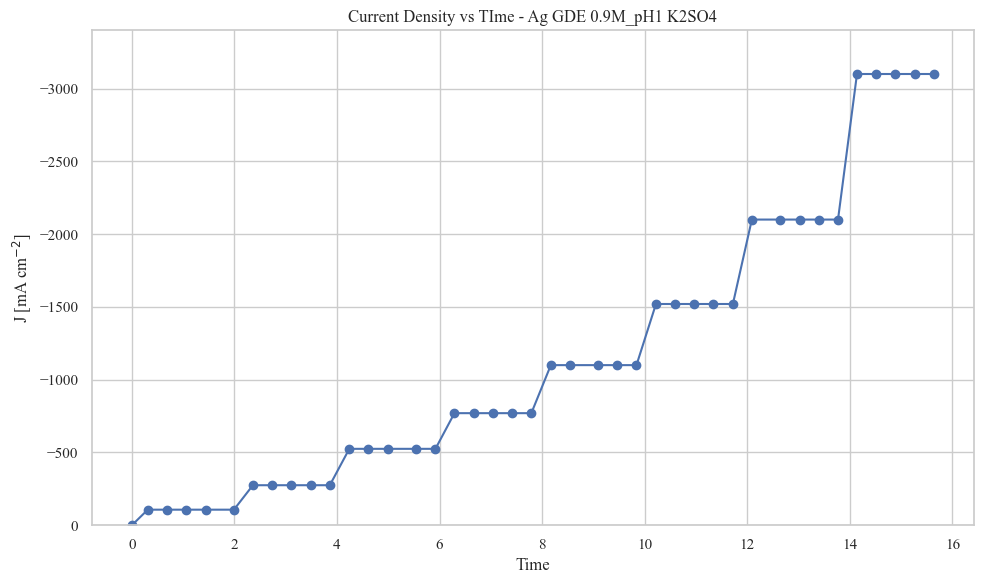

In [183]:
plt.figure(figsize=(10, 6)) 
plt.plot(Book["Duration / h"], Book['Current Density'], marker='o')  

plt.title('Current Density vs TIme - Ag GDE 0.9M_pH1 K2SO4')  
plt.xlabel('Time') 
plt.ylabel(r'J [mA cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0,-3400)
# plt.gca().set_xticklabels([])
# plt.xticks([])
plt.tight_layout()

plt.show()

## Current Density vs Flow Rate

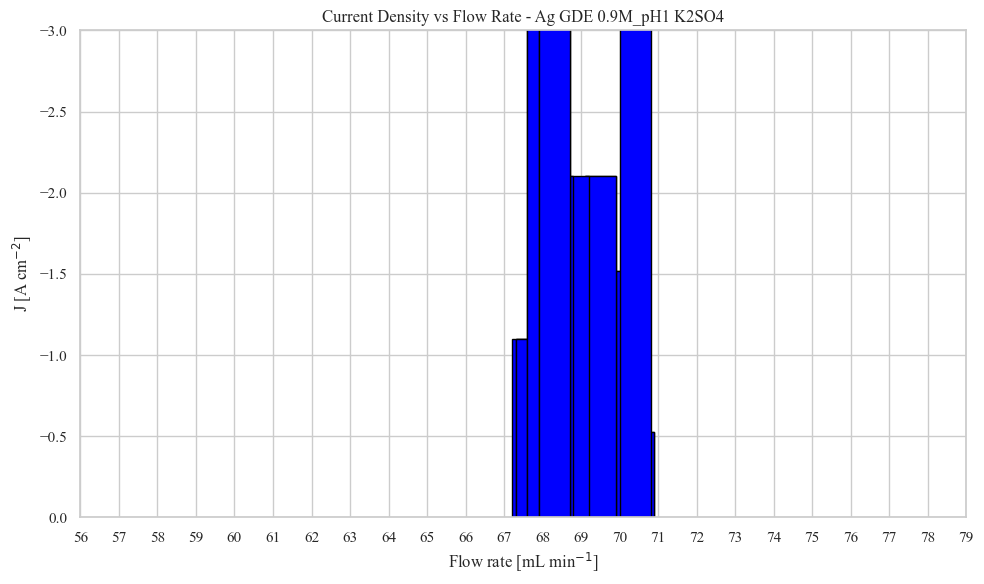

In [184]:
plt.figure(figsize=(10, 6)) 
plt.bar(Book["Flow rate (ml min-1)"], Book['Applied current / A'], color='blue', edgecolor='black')
plt.title('Current Density vs Flow Rate - Ag GDE 0.9M_pH1 K2SO4')  
plt.xlabel(r'Flow rate [mL min$^{-1}$]') 
plt.ylabel(r'J [A cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0, -3)
# plt.gca().set_xticklabels([])
plt.xticks(range(56,80,1))
plt.tight_layout()

plt.show()

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


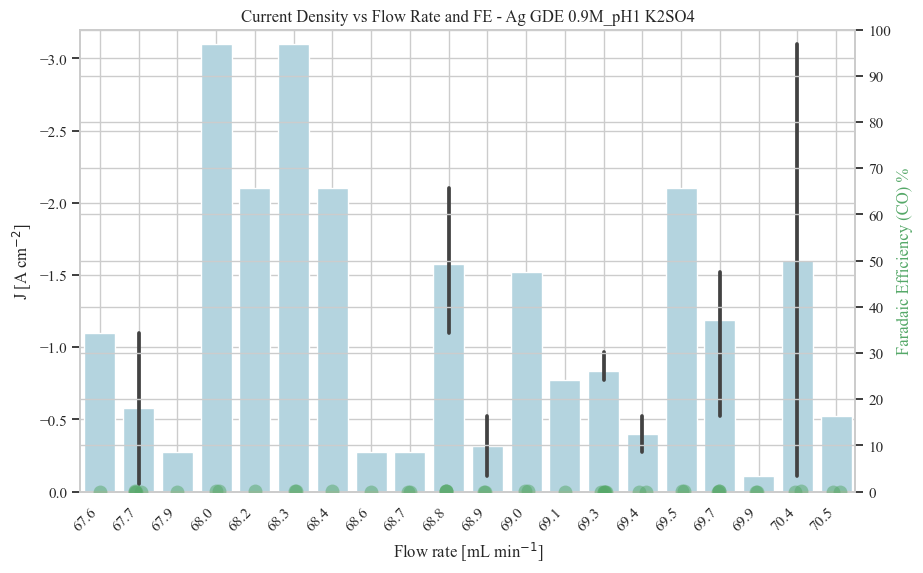

In [185]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis

sns.barplot(data=Book, x='Flow rate (ml min-1)', y='Applied current / A', ax=ax1, color='lightblue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Flow Rate and FE - Ag GDE 0.9M_pH1 K2SO4')
ax1.set_xlabel(r'Flow rate [mL min$^{-1}$]')
ax1.set_ylabel(r'J [A cm$^{-2}$]')
ax1.set_ylim(0, -3.2)
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=Book, x='Flow rate (ml min-1)',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=.5, legend=False, color='g')

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color='g')
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))

# plt.savefig('20240607_Ag_GDE_0_9M_pH1_CD_FL_FE_barplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [186]:
# g = sns.JointGrid(data=Book, x='Flow rate (ml min-1)',  y='Applied current / A', hue = 'FE(CO)')
# g.plot(sns.histplot, sns.kdeplot)

In [187]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\K2SO4\20240607 - Ag60 GDE_0.9 M K2SO4_pH1

11-Aug-26  04:05 PM    <DIR>          .
07-Jun-26  07:23 PM    <DIR>          ..
07-Jun-26  08:59 PM    <DIR>          .ipynb_checkpoints
10-Jun-24  02:39 PM           137,757 0p9M_pH1 K2SO4_20240610_1239_1min - Copy.xlsx
29-Jul-26  06:36 PM           113,714 0p9M_pH1 K2SO4_20240610_1239_1min.xlsx
10-Jun-24  02:39 PM            32,283 0p9M_pH1 K2SO4_20240610_1239_5min.xlsx
10-Jun-24  02:39 PM           962,711 0p9M_pH1 K2SO4_20240610_1239_Line_1.csv
12-May-25  11:18 AM           812,967 20240607 - Ag60 GDE_0.9 M K2SO4_pH1.ipynb
11-Aug-26  04:05 PM           704,052 20240607 - Ag60 GDE_0.9 M K2SO4_pH1-CORRECTED.ipynb
11-Aug-26  08:49 AM               556 20240607_0.9 M K2SO4_pH1_Energy Consumption.csv
11-Aug-26  08:55 AM             5,802 20240607_0.9M K2SO4_pH1.csv
11-Aug-26  08:49 AM             1,407 20

## Current Density vs Duration (h)

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


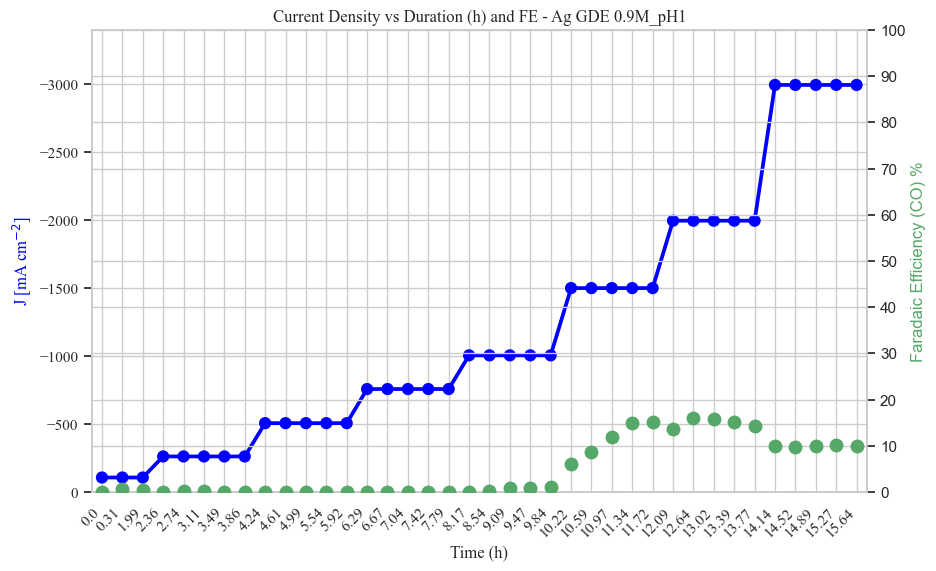

In [188]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis
sns.set(style="whitegrid")
sns.pointplot(data=rows, x='Duration / h', y='Current Density', ax=ax1, color='blue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Duration (h) and FE - Ag GDE 0.9M_pH1')
ax1.set_xlabel('Time (h)')
ax1.set_ylabel(r'J [mA cm$^{-2}$]', color='blue')
ax1.set_ylim(0, -3400)
ax1.set_yticks(np.arange(0, -3400, -500))
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=rows, x='Duration / h',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=1, legend=False, color = "g")

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color = "g")
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))
# ax2.set_xticks(np.arange(0, 18, 1))
# ax2.set_xticklabels(np.arange(0, 18, 1))

# plt.savefig('20240607_Ag_GDE_0_9M_pH1_CD_Durat_FE_lineplot.png', dpi=300, bbox_inches='tight')
plt.show()

## Current Density vs FE(CO)_ mean and std

### Stacked bar plot

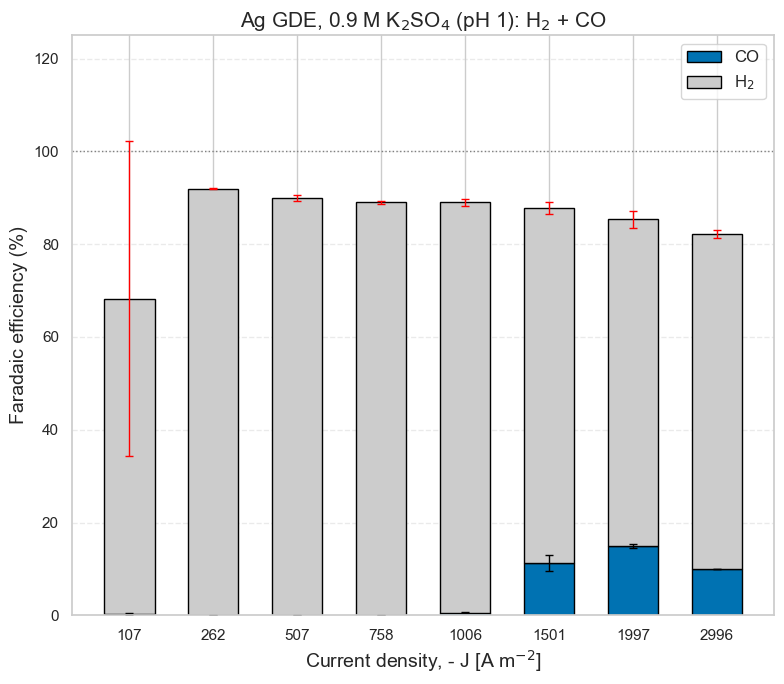

In [189]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_mean"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_mean"], w,
       bottom=summary["FE_CO_mean"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (bottom segment)
ax.errorbar(x, summary["FE_CO_mean"],
            yerr=summary["FE_CO_sem"],
            fmt="none", ecolor="black", capsize=3, lw=1)

# Error bars for H2 (top segment → must be shifted by CO)
ax.errorbar(x, summary["FE_CO_mean"] + summary["FE_H2_mean"],
            yerr=summary["FE_H2_sem"],
            fmt="none", ecolor="red", capsize=3, lw=1)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.9 M K$_2$SO$_4$ (pH 1): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_mean"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked.png", dpi=300, bbox_inches="tight")
plt.show()

## Median

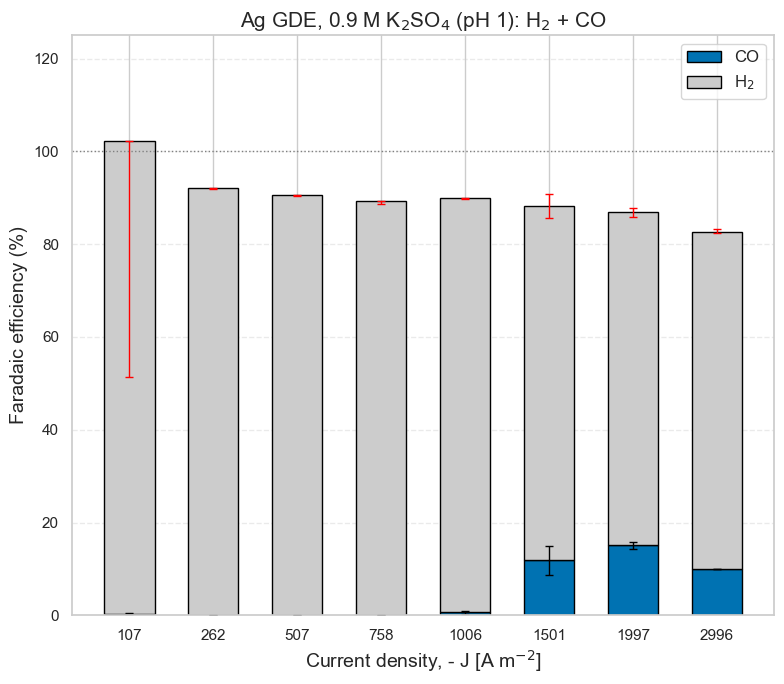

In [192]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_median"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_median"], w,
       bottom=summary["FE_CO_median"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (median + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"],
    yerr=[
        summary["FE_CO_err_low"],
        summary["FE_CO_err_high"]
    ],
    fmt="none",
    ecolor="black",
    capsize=3,
    lw=1
)

# Error bars for H2 (shifted by CO + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"] + summary["FE_H2_median"],
    yerr=[
        summary["FE_H2_err_low"],
        summary["FE_H2_err_high"]
    ],
    fmt="none",
    ecolor="red",
    capsize=3,
    lw=1
)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.9 M K$_2$SO$_4$ (pH 1): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_median"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked_median_IQR.png", dpi=300, bbox_inches="tight")
plt.show()

# Mean and Standard Deviation Applied Current and FE(CO)

In [193]:
standard_current_density = [
    100, 250, 500, 750,
    1000, 1500, 2000, 3000
]
summary["J (A m-2)_ps"] = summary["J (A m-2)"]
summary["J (A m-2)"] = standard_current_density #This is to have the same basis for later compare different experiments

In [194]:
Res_Book = summary.copy()

Res_Book = Res_Book.fillna(0)

Res_Book = Res_Book.rename(columns={
    # Mean
    "FE_H2_mean": "FE(H2)_mean",
    "FE_CO_mean": "FE(CO)_mean",
    "FE_total_mean": "FE(total)_mean",

    # Median
    "FE_H2_median": "FE(H2)_median",
    "FE_CO_median": "FE(CO)_median",
    "FE_total_median": "FE(total)_median",

    # Median error
    "FE_H2_q25": "FE(H2)_q25",
    "FE_H2_q75": "FE(H2)_q75",
    "FE_H2_err_low": "FE(H2)_err_low",
    "FE_H2_err_high": "FE(H2)_err_high",

    "FE_CO_q25": "FE(CO)_q25",
    "FE_CO_q75": "FE(CO)_q75",
    "FE_CO_err_low": "FE(CO)_err_low",
    "FE_CO_err_high": "FE(CO)_err_high",

    "FE_total_q25": "FE(total)_q25",
    "FE_total_q75": "FE(total)_q75",
    "FE_total_err_low": "FE(total)_err_low",
    "FE_total_err_high": "FE(total)_err_high",

    # SEM
    "FE_H2_sem": "FE(H2)_sem",
    "FE_CO_sem": "FE(CO)_sem",
    "FE_total_sem": "FE(total)_sem",

    # Standard deviation
    "FE_H2_std": "FE(H2)_std",
    "FE_CO_std": "FE(CO)_std",
    "FE_total_std": "FE(total)_std",

    # Current density
    "Current Density [A/m2]": "Current Density_mean"
})

Res_Book

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,67.908212,0.314696,101.771099,0.378757,33.954147,0.166310,58.810307,0.288058,50.885550,...,0.015722,3,50.885550,0.091218,0.189378,0.093287,51.166146,0.002068,0–2,107
1,250,91.861749,0.120567,91.970554,0.115103,0.109842,0.004558,0.245615,0.010193,91.777003,...,0.032348,5,0.193550,0.018971,0.000645,0.009825,0.202696,0.002415,2–4,262
2,500,89.955950,0.072118,90.602370,0.068166,0.627677,0.007506,1.403529,0.016785,90.377352,...,0.058605,5,0.225018,0.015927,0.009223,0.013761,0.237592,0.029688,4–6,507
3,750,88.927538,0.046412,89.233136,0.044799,0.255106,0.003778,0.570434,0.008447,88.680334,...,0.083442,5,0.552802,0.056301,0.000587,0.003077,0.564197,0.032932,6–8,758
4,1000,88.381373,0.613632,89.122747,0.785828,0.724321,0.175464,1.619630,0.392349,88.927400,...,0.106483,5,0.195347,0.048966,0.496183,0.092015,0.691530,0.140981,8–10,1006
5,1500,76.524131,11.313054,76.463364,11.820914,1.269269,1.775357,2.838172,3.969819,73.718549,...,0.133149,5,2.744815,2.581311,3.210781,3.040369,0.629470,0.295554,10–12,1501
6,2000,70.412657,14.949362,71.826320,15.080224,1.841515,0.468375,4.117753,1.047319,70.663590,...,0.161991,5,1.162730,0.815805,0.833412,0.665823,0.803689,0.149982,12–14,1997
7,3000,72.168289,10.012409,72.665535,9.969406,0.904484,0.068939,2.022487,0.154152,72.499672,...,0.235216,5,0.165863,0.692547,0.017038,0.103108,0.079002,1.026006,14–16,2996


In [197]:
Res_Book
# Res_Book.to_csv('20240607_0.9M K2SO4_pH1.csv')

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,67.908212,0.314696,101.771099,0.378757,33.954147,0.166310,58.810307,0.288058,50.885550,...,0.015722,3,50.885550,0.091218,0.189378,0.093287,51.166146,0.002068,0–2,107
1,250,91.861749,0.120567,91.970554,0.115103,0.109842,0.004558,0.245615,0.010193,91.777003,...,0.032348,5,0.193550,0.018971,0.000645,0.009825,0.202696,0.002415,2–4,262
2,500,89.955950,0.072118,90.602370,0.068166,0.627677,0.007506,1.403529,0.016785,90.377352,...,0.058605,5,0.225018,0.015927,0.009223,0.013761,0.237592,0.029688,4–6,507
3,750,88.927538,0.046412,89.233136,0.044799,0.255106,0.003778,0.570434,0.008447,88.680334,...,0.083442,5,0.552802,0.056301,0.000587,0.003077,0.564197,0.032932,6–8,758
4,1000,88.381373,0.613632,89.122747,0.785828,0.724321,0.175464,1.619630,0.392349,88.927400,...,0.106483,5,0.195347,0.048966,0.496183,0.092015,0.691530,0.140981,8–10,1006
5,1500,76.524131,11.313054,76.463364,11.820914,1.269269,1.775357,2.838172,3.969819,73.718549,...,0.133149,5,2.744815,2.581311,3.210781,3.040369,0.629470,0.295554,10–12,1501
6,2000,70.412657,14.949362,71.826320,15.080224,1.841515,0.468375,4.117753,1.047319,70.663590,...,0.161991,5,1.162730,0.815805,0.833412,0.665823,0.803689,0.149982,12–14,1997
7,3000,72.168289,10.012409,72.665535,9.969406,0.904484,0.068939,2.022487,0.154152,72.499672,...,0.235216,5,0.165863,0.692547,0.017038,0.103108,0.079002,1.026006,14–16,2996


## Mean and StD of FE(CO) through time

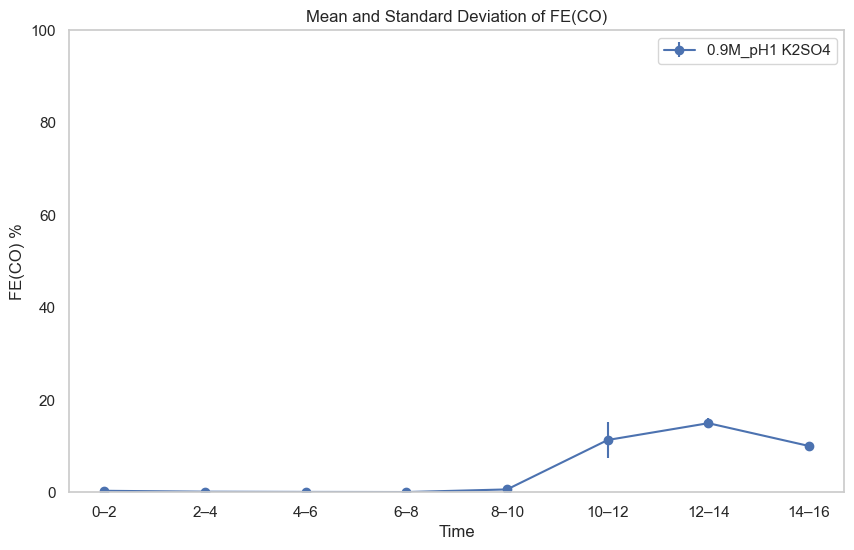

In [198]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation
ax.errorbar(Res_Book["Time Interval (h)"], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_std'], fmt='-o', label='0.9M_pH1 K2SO4')

# Formatting the plot
ax.set_xlabel('Time')
ax.set_ylabel('FE(CO) %')
ax.set_title('Mean and Standard Deviation of FE(CO)')
ax.set_ylim(0,100)
ax.legend()
ax.grid(False)

# plt.savefig('20240607_0.9M_pH1_mean_std_time.png', dpi=300, bbox_inches='tight')
plt.show()

## Current Density vs FE(CO)_ mean and std

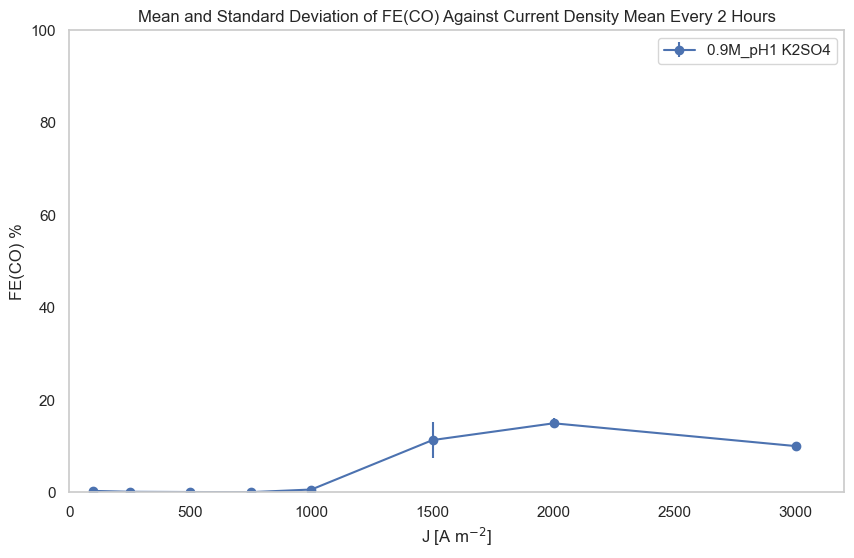

In [199]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation against Applied Current mean
ax.errorbar(Res_Book['J (A m-2)'], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_std'], fmt='-o', label='0.9M_pH1 K2SO4')

# Formatting the plot
ax.set_xlabel(r'J [A m$^{-2}$]')
ax.set_ylabel('FE(CO) %')
ax.set_xlim(0,3200)
ax.set_ylim(0,100)
ax.set_title('Mean and Standard Deviation of FE(CO) Against Current Density Mean Every 2 Hours')
ax.legend()
ax.grid(False)

# plt.savefig('20240607_0.9M_pH1_mean_std_FE(CO)vsCD.png', dpi=300, bbox_inches='tight')
plt.show()